In [1]:
# 1. Objective:  Detect if given URL is Phishing link
# 2. Identfy target variables, here ---> Legitimate or Illegitimate(status)
# 3. Understand evaluation metrics

In [2]:
# 4 Load Dataset
import pandas as pd
df = pd.read_csv("final_dataset.csv")
print(df.head())

                                                 url  length_url  \
0              http://www.crestonwood.com/router.php          37   
1  http://shadetreetechnology.com/V4/validation/a...          77   
2  https://support-appleld.com.secureupdate.duila...         126   
3                                 http://rgipt.ac.in          18   
4  http://www.iracing.com/tracks/gateway-motorspo...          55   

   length_hostname  ip  nb_hyphens  nb_dots  nb_at  nb_and  nb_underscore  \
0               19   0           0        3      0       0              0   
1               23   1           0        1      0       0              0   
2               50   1           1        4      0       2              2   
3               11   0           0        2      0       0              0   
4               15   0           2        2      0       0              0   

   nb_percent  ...  iframe  domain_with_copyright  whois_registered_domain  \
0           0  ...       0                      1 

In [3]:
# 5. Initial Data Inspection
df.head()

,url,length_url,length_hostname,ip,nb_hyphens,nb_dots,nb_at,nb_and,nb_underscore,nb_percent,...,iframe,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,page_rank,status,has_https
0,http://www.crestonwood.com/router.php,37,19,0,0,3,0,0,0,0,...,0,1,0,45,-1,0,1,4,legitimate,0
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,0,1,0,0,0,0,...,0,0,0,77,5767,0,0,2,phishing,0
2,https://support-appleld.com.secureupdate.duila...,126,50,1,1,4,0,2,2,0,...,0,0,0,14,4004,5828815,0,0,phishing,1
3,http://rgipt.ac.in,18,11,0,0,2,0,0,0,0,...,0,0,0,62,-1,107721,0,3,legitimate,0
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,6,legitimate,0


In [4]:
df.tail()

,url,length_url,length_hostname,ip,nb_hyphens,nb_dots,nb_at,nb_and,nb_underscore,nb_percent,...,iframe,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,page_rank,status,has_https
11425,http://www.fontspace.com/category/blackletter,45,17,0,0,2,0,0,0,0,...,0,0,0,448,5396,3980,0,6,legitimate,0
11426,http://www.budgetbots.com/server.php/Server%20...,84,18,0,0,5,1,0,0,1,...,0,0,0,211,6728,0,0,0,phishing,0
11427,https://www.facebook.com/Interactive-Televisio...,105,16,1,6,2,0,0,1,0,...,0,0,0,2809,8515,8,0,10,legitimate,1
11428,http://www.mypublicdomainpictures.com/,38,30,0,0,2,0,0,0,0,...,0,0,0,85,2836,2455493,0,4,legitimate,0
11429,http://174.139.46.123/ap/signin?openid.pape.ma...,477,14,1,0,24,1,9,18,23,...,0,1,1,0,-1,0,1,0,phishing,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   url                         11430 non-null  object
 1   length_url                  11430 non-null  int64 
 2   length_hostname             11430 non-null  int64 
 3   ip                          11430 non-null  int64 
 4   nb_hyphens                  11430 non-null  int64 
 5   nb_dots                     11430 non-null  int64 
 6   nb_at                       11430 non-null  int64 
 7   nb_and                      11430 non-null  int64 
 8   nb_underscore               11430 non-null  int64 
 9   nb_percent                  11430 non-null  int64 
 10  nb_slash                    11430 non-null  int64 
 11  nb_colon                    11430 non-null  int64 
 12  nb_comma                    11430 non-null  int64 
 13  port                        11430 non-null  in

In [6]:
df.describe()

,length_url,length_hostname,ip,nb_hyphens,nb_dots,nb_at,nb_and,nb_underscore,nb_percent,nb_slash,...,login_form,iframe,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,page_rank,has_https
count,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,...,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,1.143000e+04,11430.000000,11430.000000,11430.000000
mean,61.126684,21.090289,0.150569,0.997550,2.480752,0.022222,0.162292,0.322660,0.123097,4.289589,...,0.063605,0.001312,0.439545,0.072878,492.532196,4062.543745,8.567566e+05,0.020122,3.185739,0.389064
std,55.297318,10.777171,0.357644,2.087087,1.369686,0.155500,0.821337,1.093336,1.466450,1.882251,...,0.244058,0.036204,0.496353,0.259948,814.769415,3107.784600,1.995606e+06,0.140425,2.536955,0.487559
min,12.000000,4.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,-1.000000,-12.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,33.000000,15.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,84.000000,972.250000,0.000000e+00,0.000000,1.000000,0.000000
50%,47.000000,19.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,242.000000,3993.000000,1.651000e+03,0.000000,3.000000,0.000000
75%,71.000000,24.000000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,5.000000,...,0.000000,0.000000,1.000000,0.000000,449.000000,7026.750000,3.738455e+05,0.000000,5.000000,1.000000
max,1641.000000,214.000000,1.000000,43.000000,24.000000,4.000000,19.000000,18.000000,96.000000,33.000000,...,1.000000,1.000000,1.000000,1.000000,29829.000000,12874.000000,1.076799e+07,1.000000,10.000000,1.000000


In [7]:
df.dtypes

url                           object
length_url                     int64
length_hostname                int64
ip                             int64
nb_hyphens                     int64
nb_dots                        int64
nb_at                          int64
nb_and                         int64
nb_underscore                  int64
nb_percent                     int64
nb_slash                       int64
nb_colon                       int64
nb_comma                       int64
port                           int64
tld_in_path                    int64
tld_in_subdomain               int64
shortening_service             int64
path_extension                 int64
nb_redirection                 int64
nb_external_redirection        int64
login_form                     int64
iframe                         int64
domain_with_copyright          int64
whois_registered_domain        int64
domain_registration_length     int64
domain_age                     int64
web_traffic                    int64
d

In [8]:
df.shape

(11430, 31)

In [9]:
df = df.drop('page_rank', axis=1)

In [10]:
# 6. Data Cleaning
df.isnull().sum()

url                           0
length_url                    0
length_hostname               0
ip                            0
nb_hyphens                    0
nb_dots                       0
nb_at                         0
nb_and                        0
nb_underscore                 0
nb_percent                    0
nb_slash                      0
nb_colon                      0
nb_comma                      0
port                          0
tld_in_path                   0
tld_in_subdomain              0
shortening_service            0
path_extension                0
nb_redirection                0
nb_external_redirection       0
login_form                    0
iframe                        0
domain_with_copyright         0
whois_registered_domain       0
domain_registration_length    0
domain_age                    0
web_traffic                   0
dns_record                    0
status                        0
has_https                     0
dtype: int64

In [11]:
df.duplicated().sum()

0

In [12]:
df.dtypes

url                           object
length_url                     int64
length_hostname                int64
ip                             int64
nb_hyphens                     int64
nb_dots                        int64
nb_at                          int64
nb_and                         int64
nb_underscore                  int64
nb_percent                     int64
nb_slash                       int64
nb_colon                       int64
nb_comma                       int64
port                           int64
tld_in_path                    int64
tld_in_subdomain               int64
shortening_service             int64
path_extension                 int64
nb_redirection                 int64
nb_external_redirection        int64
login_form                     int64
iframe                         int64
domain_with_copyright          int64
whois_registered_domain        int64
domain_registration_length     int64
domain_age                     int64
web_traffic                    int64
d

In [13]:
df['status'] = df['status'].map({
    'phishing':1,
    'legitimate':0
})

In [14]:
df.dtypes

url                           object
length_url                     int64
length_hostname                int64
ip                             int64
nb_hyphens                     int64
nb_dots                        int64
nb_at                          int64
nb_and                         int64
nb_underscore                  int64
nb_percent                     int64
nb_slash                       int64
nb_colon                       int64
nb_comma                       int64
port                           int64
tld_in_path                    int64
tld_in_subdomain               int64
shortening_service             int64
path_extension                 int64
nb_redirection                 int64
nb_external_redirection        int64
login_form                     int64
iframe                         int64
domain_with_copyright          int64
whois_registered_domain        int64
domain_registration_length     int64
domain_age                     int64
web_traffic                    int64
d

In [15]:
df['status'].value_counts()

status
0    5715
1    5715
Name: count, dtype: int64

In [16]:
df.isnull().sum()

url                           0
length_url                    0
length_hostname               0
ip                            0
nb_hyphens                    0
nb_dots                       0
nb_at                         0
nb_and                        0
nb_underscore                 0
nb_percent                    0
nb_slash                      0
nb_colon                      0
nb_comma                      0
port                          0
tld_in_path                   0
tld_in_subdomain              0
shortening_service            0
path_extension                0
nb_redirection                0
nb_external_redirection       0
login_form                    0
iframe                        0
domain_with_copyright         0
whois_registered_domain       0
domain_registration_length    0
domain_age                    0
web_traffic                   0
dns_record                    0
status                        0
has_https                     0
dtype: int64

In [17]:
# URL column not needed, so remove

In [18]:
url_col = df['url']
df = df.drop('url', axis=1)

In [19]:
df.dtypes

length_url                    int64
length_hostname               int64
ip                            int64
nb_hyphens                    int64
nb_dots                       int64
nb_at                         int64
nb_and                        int64
nb_underscore                 int64
nb_percent                    int64
nb_slash                      int64
nb_colon                      int64
nb_comma                      int64
port                          int64
tld_in_path                   int64
tld_in_subdomain              int64
shortening_service            int64
path_extension                int64
nb_redirection                int64
nb_external_redirection       int64
login_form                    int64
iframe                        int64
domain_with_copyright         int64
whois_registered_domain       int64
domain_registration_length    int64
domain_age                    int64
web_traffic                   int64
dns_record                    int64
status                      

In [20]:
df.shape

(11430, 29)

In [21]:
# 7. Exploratory Data Analysis

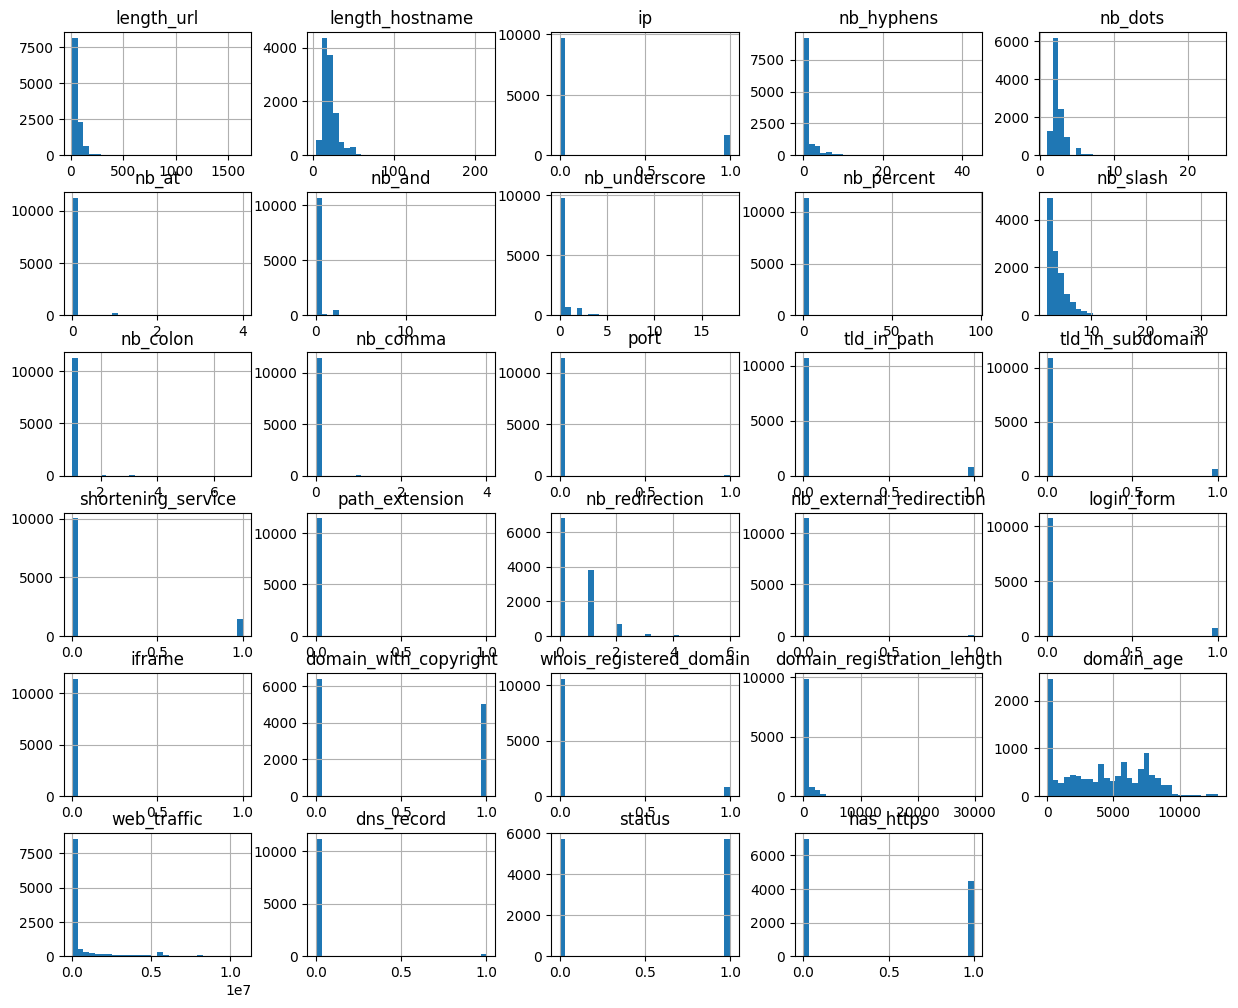

In [22]:
# a. Univariate Analysis
# Goal: Understand distribution of each feature
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].hist(figsize=(15, 12), bins=30)
plt.show()


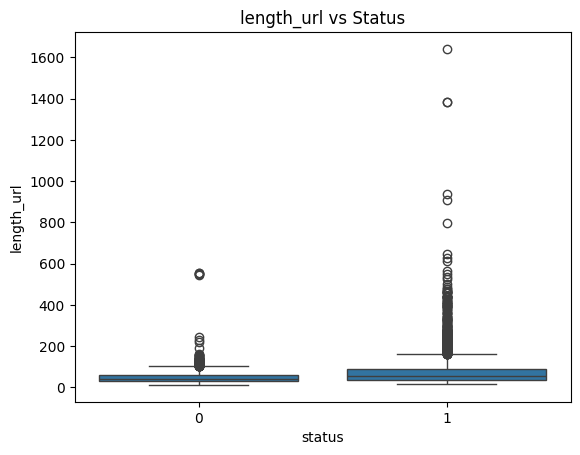

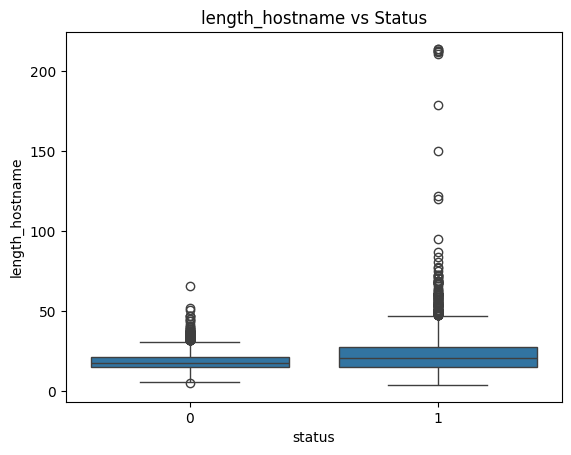

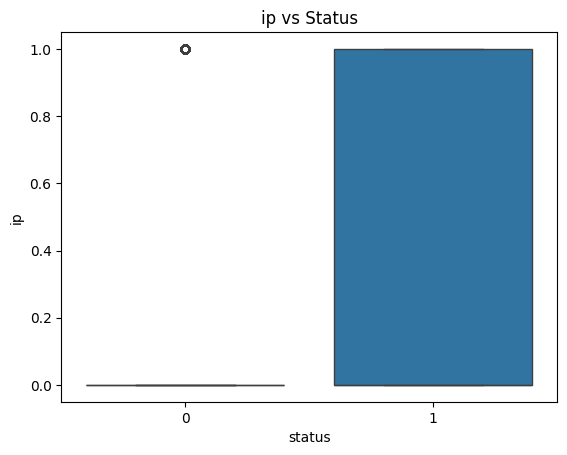

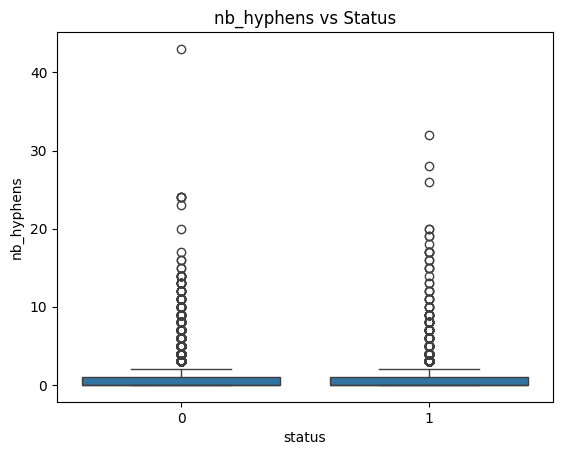

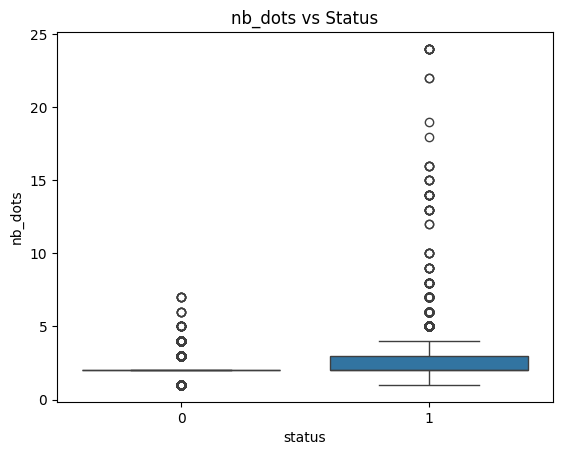

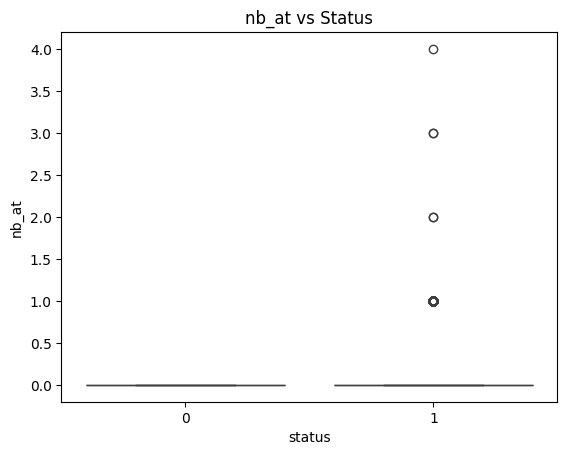

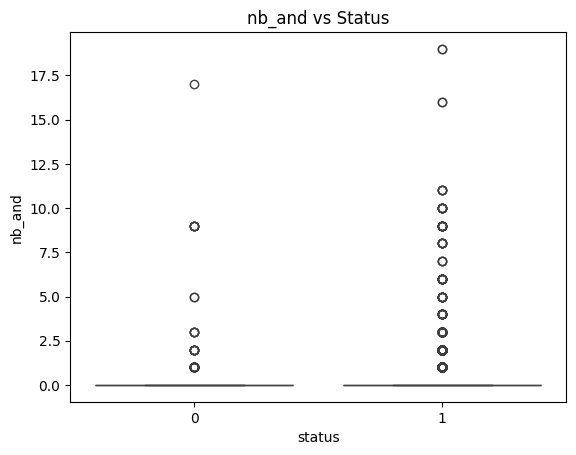

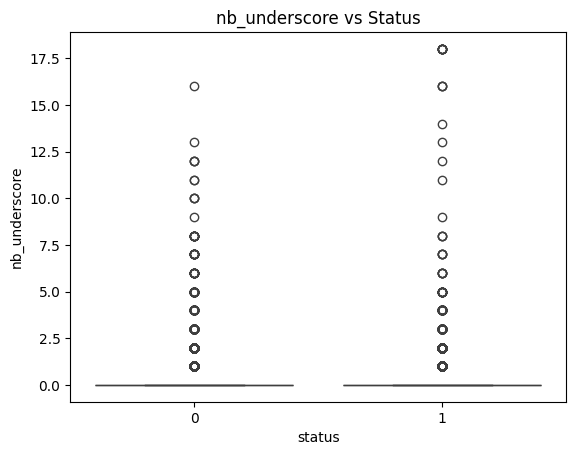

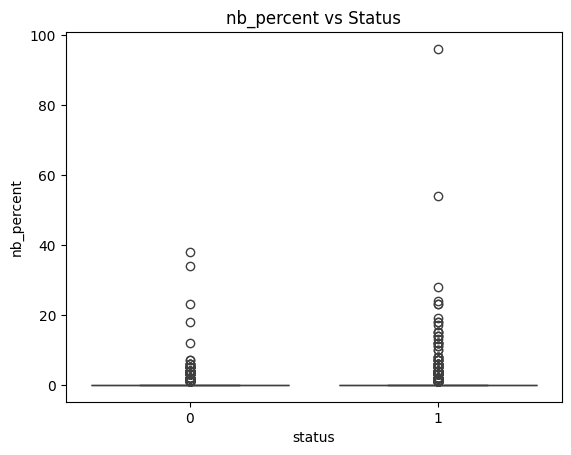

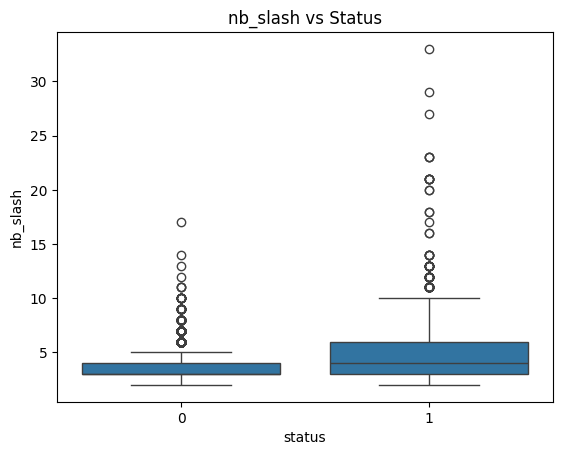

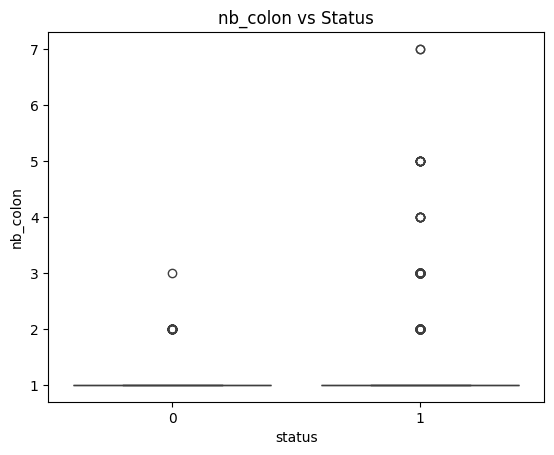

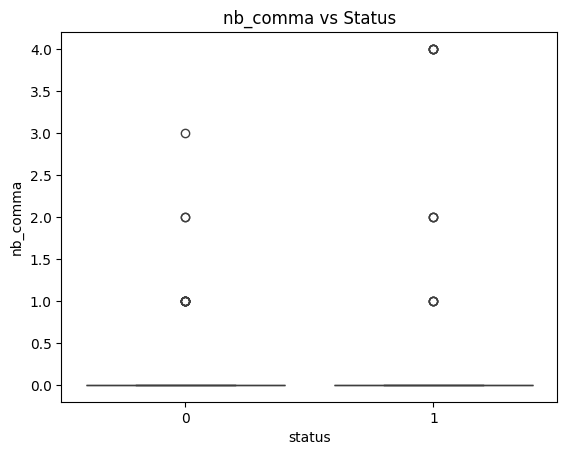

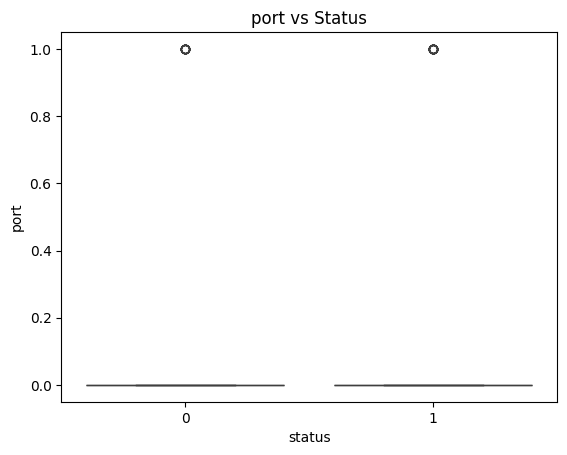

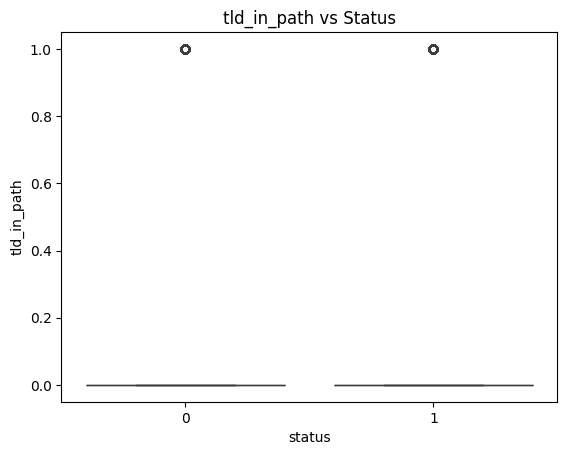

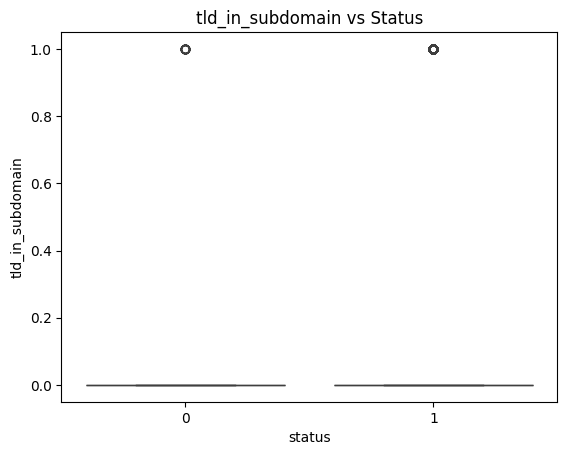

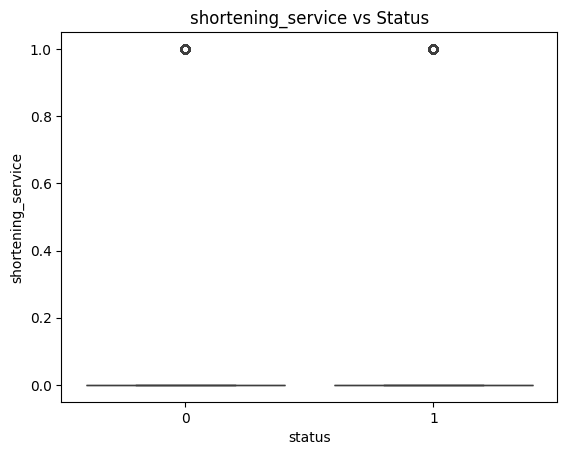

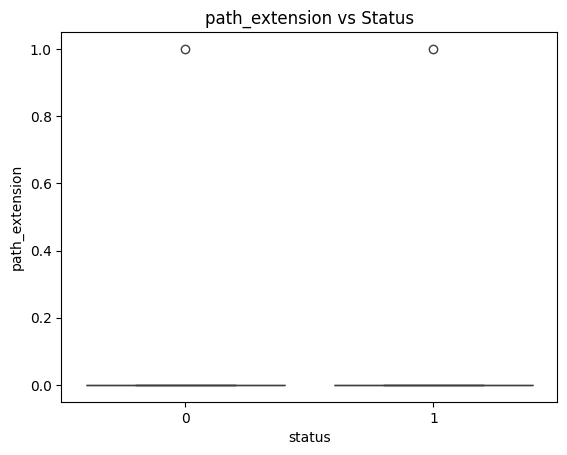

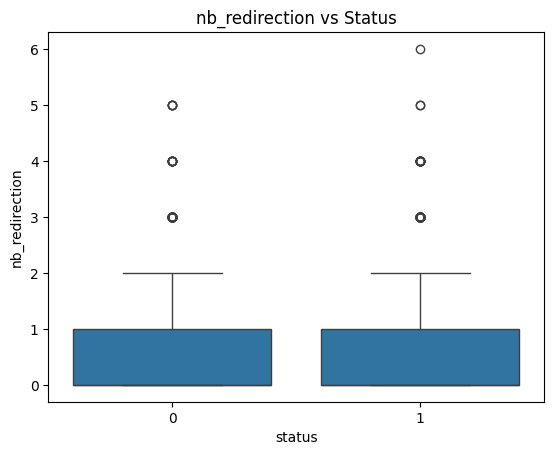

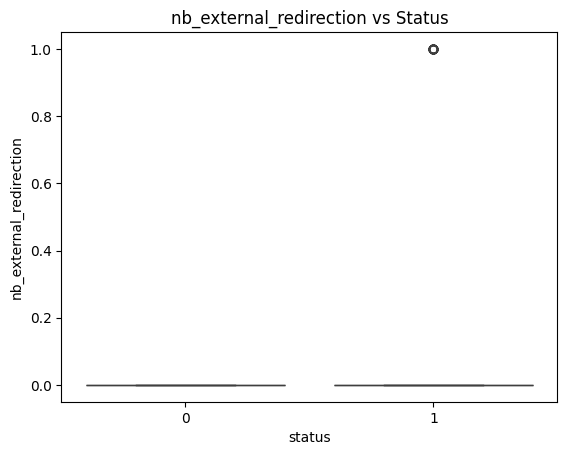

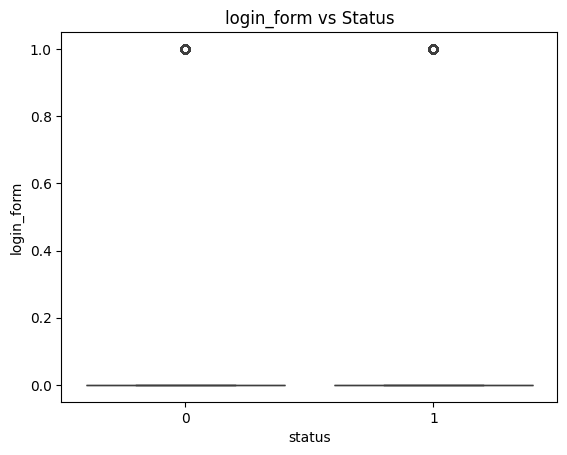

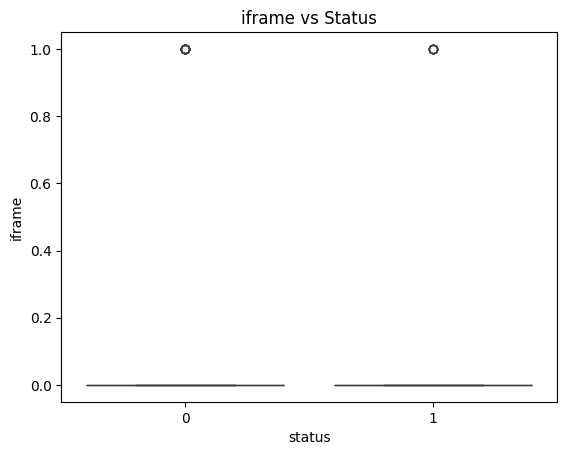

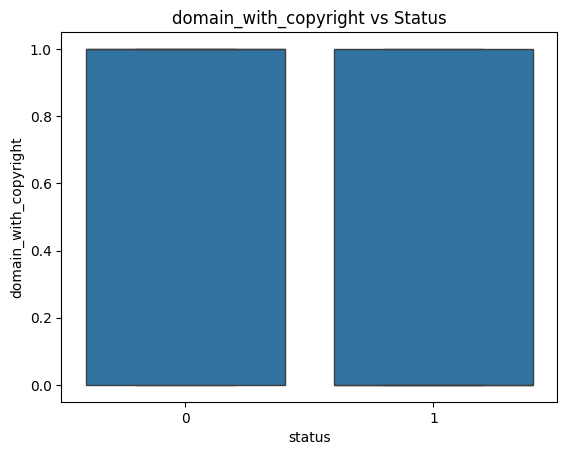

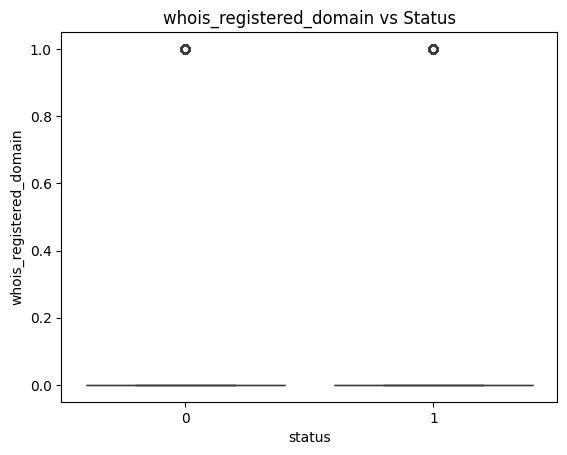

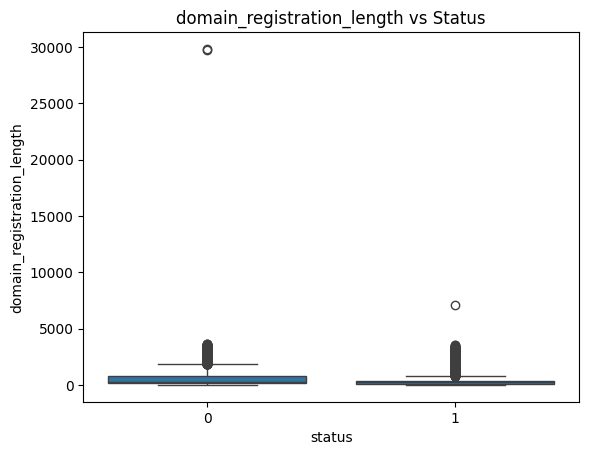

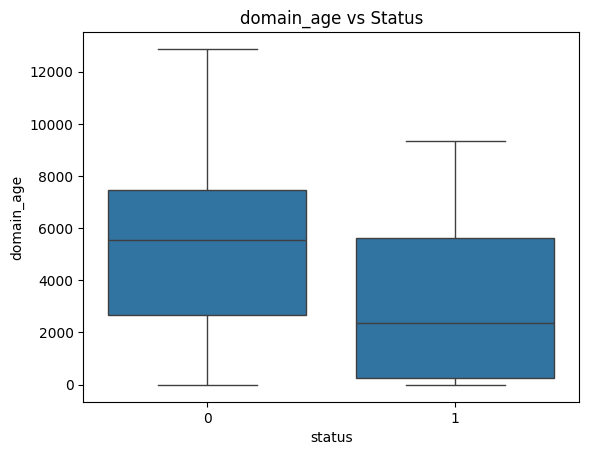

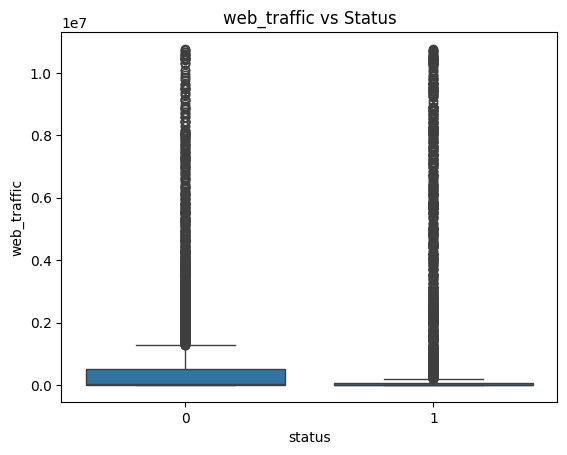

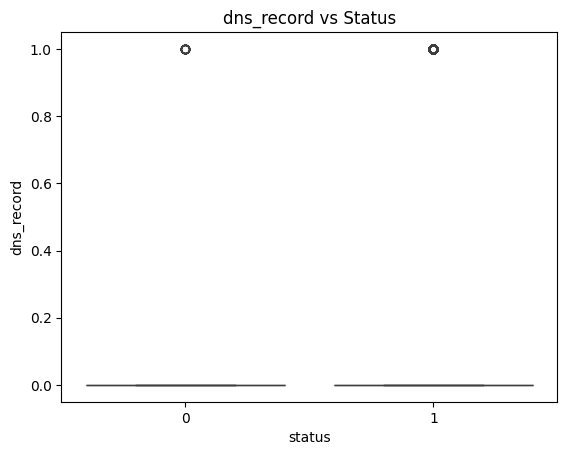

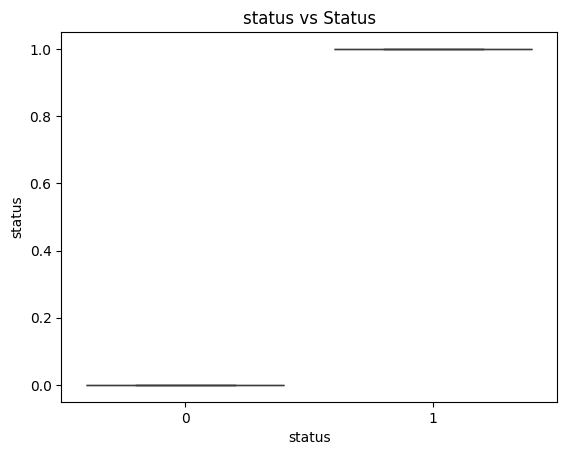

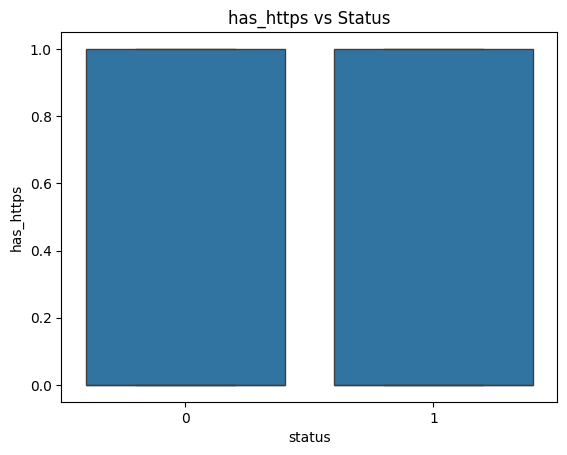

In [23]:
# 2. Bivariate Analysis (Feature vs Target)
# Goal: Compare features with status (phishing vs legitimate)
import seaborn as sns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure()
    sns.boxplot(x='status', y=col, data=df)
    plt.title(f"{col} vs Status")
    plt.show()

In [24]:
corr = df.corr(numeric_only=True)['status'].abs().sort_values(ascending=False)
print(corr)

status                        1.000000e+00
domain_age                    3.318891e-01
ip                            3.216978e-01
length_url                    2.485805e-01
nb_slash                      2.422700e-01
length_hostname               2.383224e-01
tld_in_subdomain              2.088842e-01
nb_dots                       2.070288e-01
domain_with_copyright         1.730985e-01
nb_and                        1.705464e-01
domain_registration_length    1.617188e-01
nb_at                         1.429146e-01
dns_record                    1.221190e-01
has_https                     1.146691e-01
shortening_service            1.061200e-01
nb_hyphens                    1.001075e-01
nb_colon                      9.283531e-02
tld_in_path                   7.914651e-02
whois_registered_domain       6.697907e-02
web_traffic                   6.038772e-02
nb_external_redirection       5.620994e-02
nb_underscore                 3.809134e-02
nb_percent                    2.810129e-02
nb_redirect

In [25]:
# Removing web_traffic col as not eliable
import pandas as pd

# load CSV

# drop column
df.drop(columns=['web_traffic'], inplace=True, errors='ignore')

# save back to SAME file
df.to_csv("final_dataset.csv", index=False)

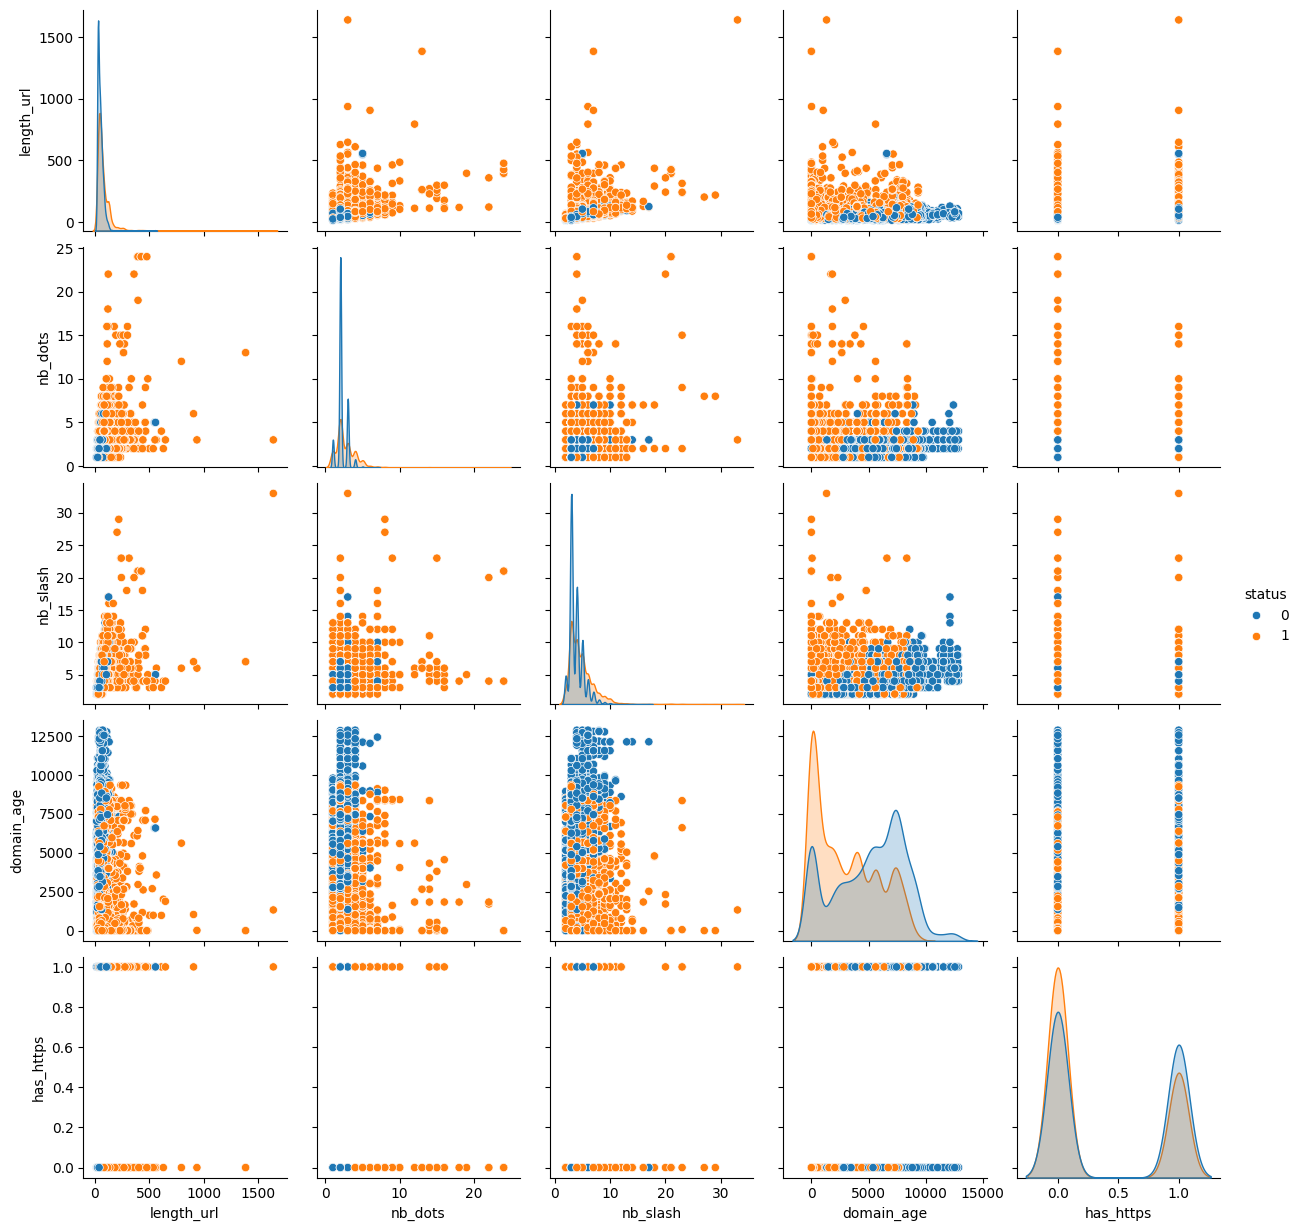

In [26]:
# 3. Multivariate Analysis (Feature relationships)
# 👉 Goal: Understand how features interact with each other

sns.pairplot(df[['length_url', 'nb_dots', 'nb_slash', 'domain_age', 'has_https','status']], hue='status')

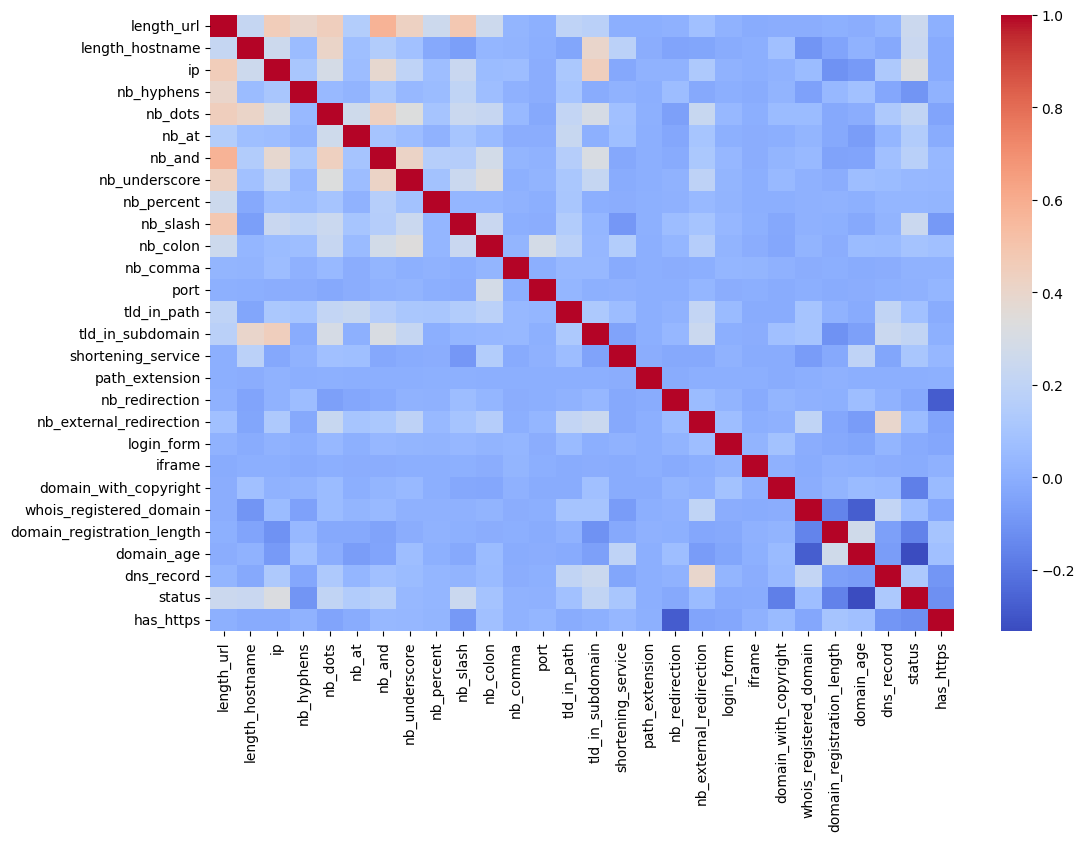

In [27]:
# 4. 🔥 Correlation Matrix / Heatmap

# 👉 MOST IMPORTANT PART OF YOUR EDA

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

<Axes: xlabel='status'>

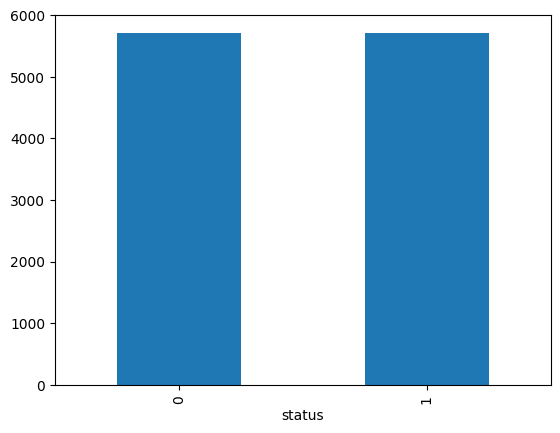

In [28]:
df['status'].value_counts().plot(kind='bar')

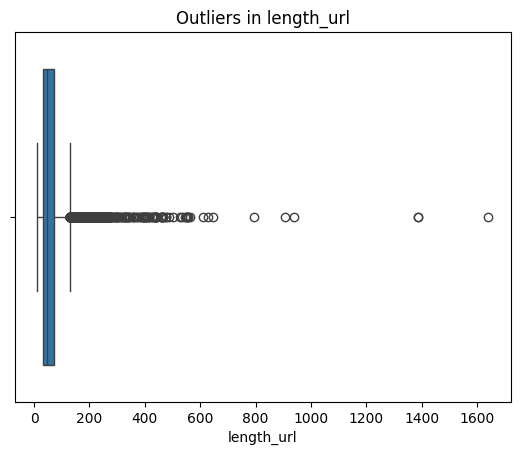

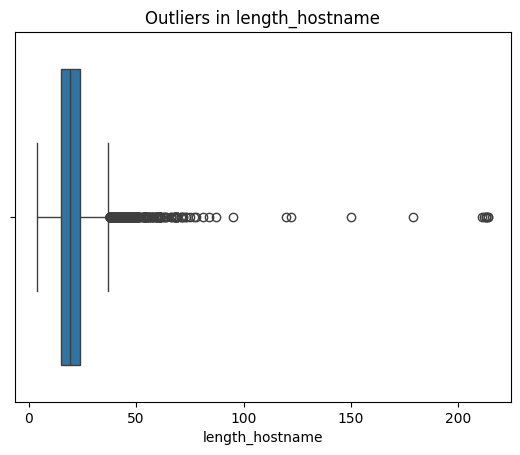

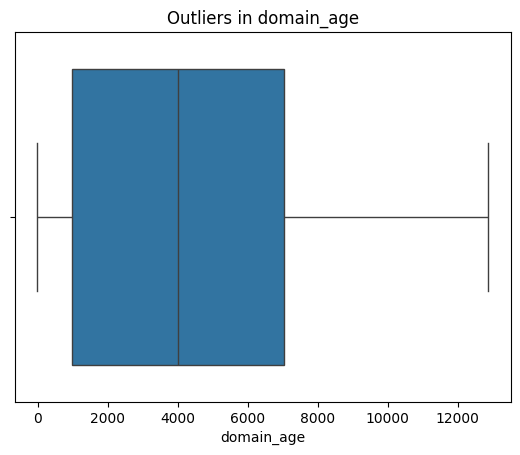

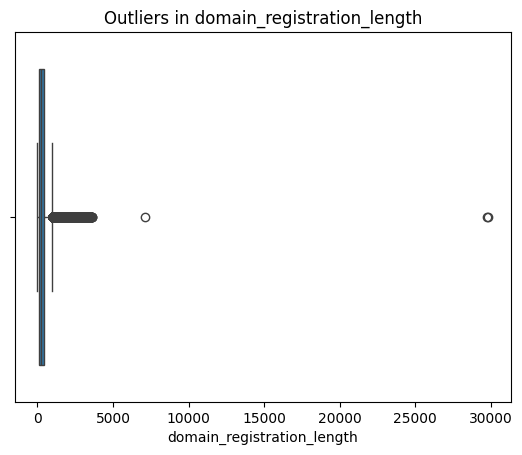

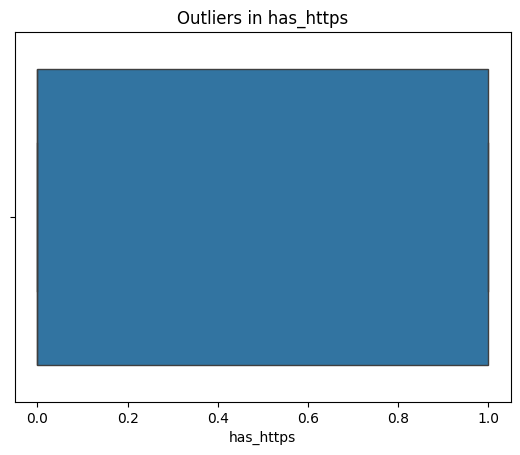

In [29]:
# 6. Outlier Detection & Treatment
continuous_cols = [
    'length_url',
    'length_hostname',
    'domain_age',
    'domain_registration_length',
    'has_https'
    
]

import seaborn as sns
import matplotlib.pyplot as plt

for col in continuous_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

In [30]:
Q1 = df[continuous_cols].quantile(0.25)
Q3 = df[continuous_cols].quantile(0.75)
IQR = Q3 - Q1

In [31]:
outlier_mask = (
    (df[continuous_cols] < (Q1 - 1.5 * IQR)) |
    (df[continuous_cols] > (Q3 + 1.5 * IQR))
)

In [32]:
outlier_counts = outlier_mask.sum()
print(outlier_counts.sort_values(ascending=False))

domain_registration_length    1529
length_hostname                775
length_url                     620
domain_age                       0
has_https                        0
dtype: int64


In [33]:
df_outliers = df[outlier_mask.any(axis=1)]
df_outliers.head()

,length_url,length_hostname,ip,nb_hyphens,nb_dots,nb_at,nb_and,nb_underscore,nb_percent,nb_slash,...,nb_external_redirection,login_form,iframe,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,dns_record,status,has_https
2,126,50,1,1,4,0,2,2,0,5,...,0,0,0,0,0,14,4004,0,1,1
16,31,22,0,0,2,0,0,0,0,3,...,0,0,0,1,0,3069,8301,0,0,1
17,50,21,0,0,2,0,0,0,0,5,...,0,0,0,1,0,1337,2316,0,1,0
24,126,50,1,1,4,0,2,2,0,4,...,0,0,0,1,0,25,3993,0,1,0
28,68,42,1,0,4,0,0,0,0,4,...,0,0,0,1,0,25,3993,0,1,0


In [34]:
# Standardization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Features and target
X = df.drop(columns=['status'])   # url already gone
y = df['status']

In [35]:
df.dtypes

length_url                    int64
length_hostname               int64
ip                            int64
nb_hyphens                    int64
nb_dots                       int64
nb_at                         int64
nb_and                        int64
nb_underscore                 int64
nb_percent                    int64
nb_slash                      int64
nb_colon                      int64
nb_comma                      int64
port                          int64
tld_in_path                   int64
tld_in_subdomain              int64
shortening_service            int64
path_extension                int64
nb_redirection                int64
nb_external_redirection       int64
login_form                    int64
iframe                        int64
domain_with_copyright         int64
whois_registered_domain       int64
domain_registration_length    int64
domain_age                    int64
dns_record                    int64
status                        int64
has_https                   

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [37]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
import pandas as pd

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

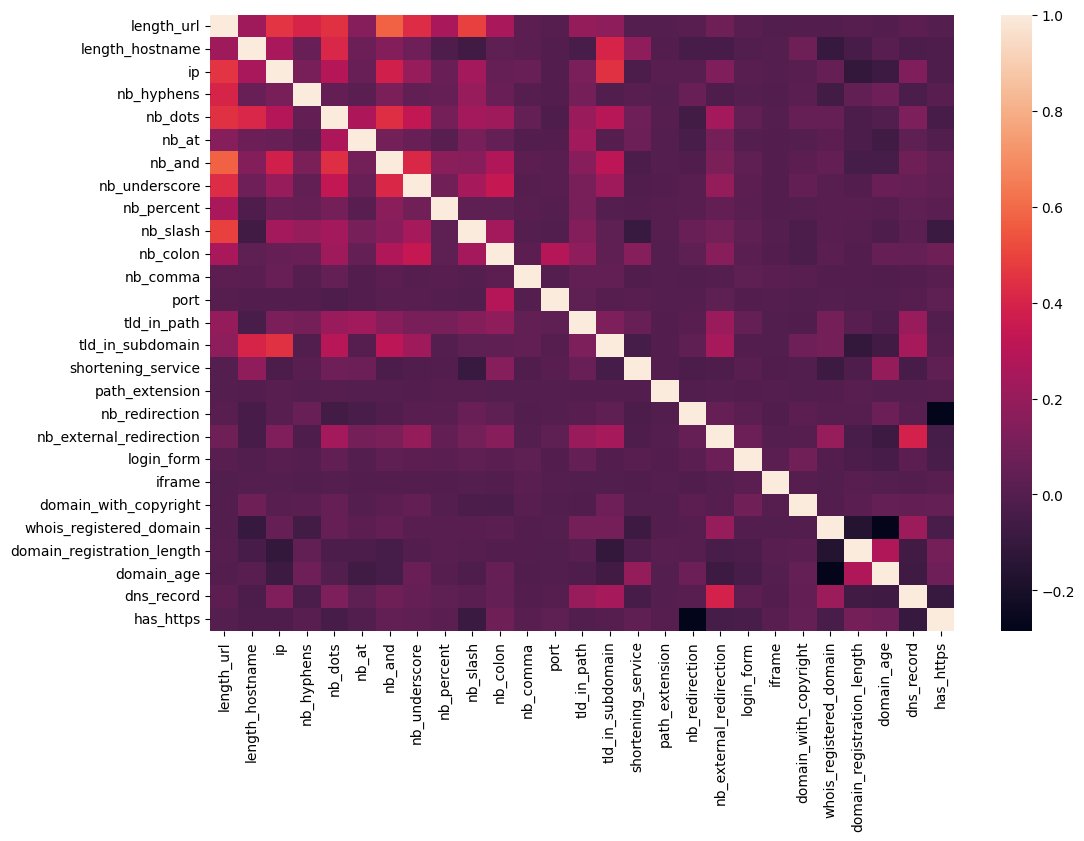

In [39]:
# 10. Feature Selection
# 🔹 (A) Correlation Filtering

import seaborn as sns
import matplotlib.pyplot as plt

corr = X.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr)
plt.show()

In [40]:
# Drop high correlation (> 0.9)
import numpy as np

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

X = X.drop(columns=to_drop)

In [41]:
# (B) Feature Importance (Tree Model)
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X, y)

importances = model.feature_importances_

In [42]:
feat_importance = pd.Series(importances, index=X.columns)
feat_importance.sort_values(ascending=False)

domain_age                    0.217572
length_url                    0.127495
domain_registration_length    0.121374
length_hostname               0.105223
nb_slash                      0.078283
nb_dots                       0.071159
nb_hyphens                    0.059532
ip                            0.046628
domain_with_copyright         0.030999
nb_redirection                0.030826
has_https                     0.020991
shortening_service            0.017112
nb_underscore                 0.016999
dns_record                    0.011502
nb_and                        0.008469
login_form                    0.008170
whois_registered_domain       0.007167
nb_percent                    0.004450
tld_in_path                   0.004264
nb_at                         0.004007
tld_in_subdomain              0.003464
nb_colon                      0.003174
iframe                        0.000480
port                          0.000376
nb_comma                      0.000156
nb_external_redirection  

In [43]:
# (C) Chi-Square Test (for categorical-heavy datasets)

from sklearn.feature_selection import SelectKBest, chi2

chi_model = SelectKBest(chi2, k=10)
X_new = chi_model.fit_transform(abs(X), y)  # chi2 needs non-negative values

In [44]:
# 11. Train-Test Split (Correct Version)
# Use stratified split (VERY IMPORTANT for classification)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
# 12. Handle Imbalanced Data
# 🔹 (A) Check imbalance
y.value_counts()



status
0    5715
1    5715
Name: count, dtype: int64

In [46]:
# # Balanced datase so 
# No bias
# No SMOTE needed
# No undersampling needed

In [47]:
X.isnull().sum()

length_url                    0
length_hostname               0
ip                            0
nb_hyphens                    0
nb_dots                       0
nb_at                         0
nb_and                        0
nb_underscore                 0
nb_percent                    0
nb_slash                      0
nb_colon                      0
nb_comma                      0
port                          0
tld_in_path                   0
tld_in_subdomain              0
shortening_service            0
path_extension                0
nb_redirection                0
nb_external_redirection       0
login_form                    0
iframe                        0
domain_with_copyright         0
whois_registered_domain       0
domain_registration_length    0
domain_age                    0
dns_record                    0
has_https                     0
dtype: int64

In [48]:
X.dtypes

length_url                    int64
length_hostname               int64
ip                            int64
nb_hyphens                    int64
nb_dots                       int64
nb_at                         int64
nb_and                        int64
nb_underscore                 int64
nb_percent                    int64
nb_slash                      int64
nb_colon                      int64
nb_comma                      int64
port                          int64
tld_in_path                   int64
tld_in_subdomain              int64
shortening_service            int64
path_extension                int64
nb_redirection                int64
nb_external_redirection       int64
login_form                    int64
iframe                        int64
domain_with_copyright         int64
whois_registered_domain       int64
domain_registration_length    int64
domain_age                    int64
dns_record                    int64
has_https                     int64
dtype: object

In [49]:
X = X.fillna(X.mean())

In [50]:
print(X.shape)
print(y.shape)

(11430, 27)
(11430,)


In [51]:
# ========================================================================
# Model Generation
# A.Random Forest

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [68]:
from sklearn.ensemble import RandomForestClassifier

# model = RandomForestClassifier(n_estimators=100, random_state=42)

model = RandomForestClassifier(
    n_estimators=900,        # more trees
    max_depth=20,            # control overfitting
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)
model.fit(X_train, y_train)

,n_estimators,900
,criterion,'gini'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [69]:
y_pred = model.predict(X_test)

In [70]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9125109361329834
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1143
           1       0.91      0.91      0.91      1143

    accuracy                           0.91      2286
   macro avg       0.91      0.91      0.91      2286
weighted avg       0.91      0.91      0.91      2286



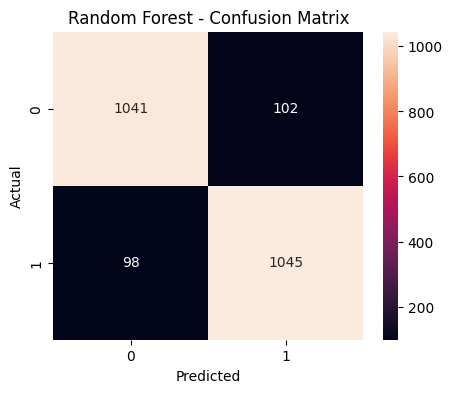

In [71]:
# Visualization

# A. Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

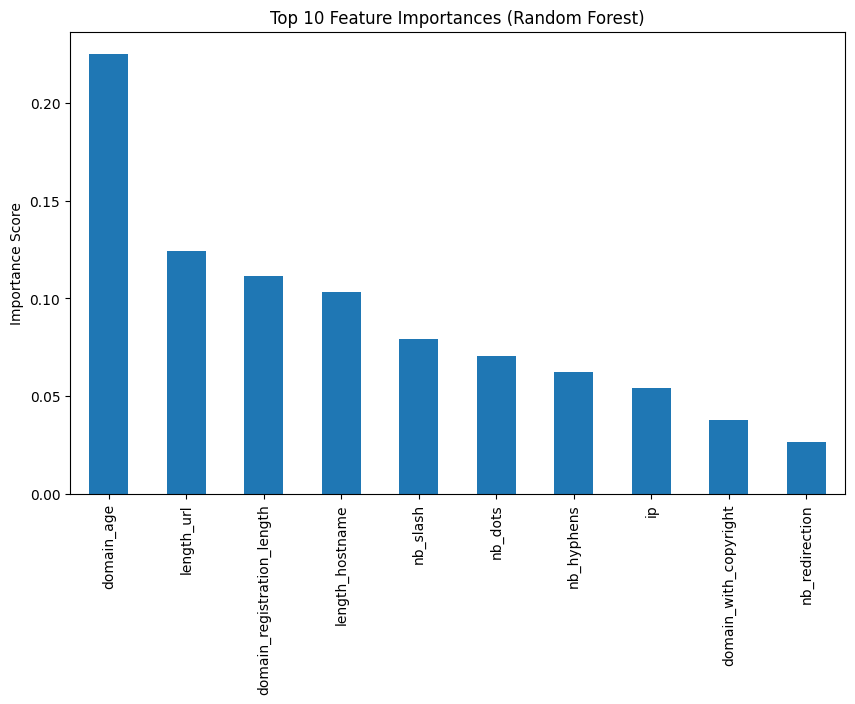

In [72]:
# 2. Feature Importance (Random Forest)
import pandas as pd
import matplotlib.pyplot as plt

importances = model.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.ylabel("Importance Score")
plt.show()

In [73]:
# from sklearn.preprocessing import LabelEncoder
# import joblib


# encoder = LabelEncoder()

# df['status'] = encoder.fit_transform(df['status'])

# joblib.dump(encoder, "encoder.pkl")

In [74]:
# import joblib

# joblib.dump(model, "model.pkl")

# # only if you used scaling
# joblib.dump(scaler, "scaler.pkl")

In [75]:
# print(df.drop('status', axis=1).columns)

In [115]:
# ========================================================================
# B. XGBoost
import sys
!{sys.executable} -m pip install xgboost


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: /home/prashant/.pyenv/versions/tf310/bin/python -m pip install --upgrade pip


In [76]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
model = xgb.XGBClassifier(
    n_estimators=1100,
    learning_rate=0.04,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [96]:
y_pred = model.predict(X_test)

In [97]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9146981627296588

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92      1143
           1       0.92      0.91      0.91      1143

    accuracy                           0.91      2286
   macro avg       0.91      0.91      0.91      2286
weighted avg       0.91      0.91      0.91      2286



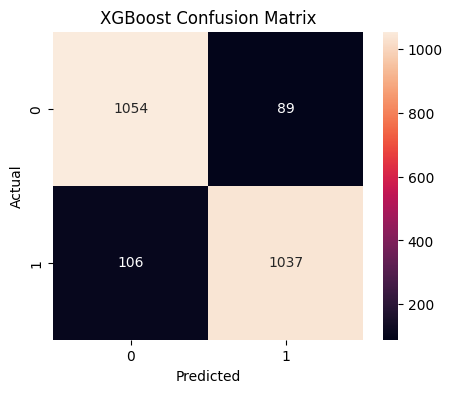

In [98]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

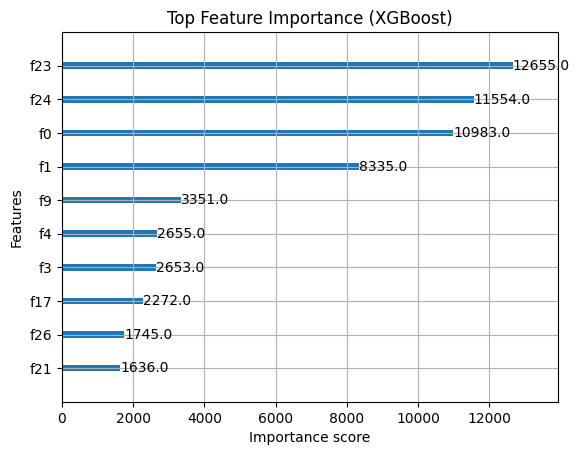

In [99]:
xgb.plot_importance(model, max_num_features=10)
plt.title("Top Feature Importance (XGBoost)")
plt.show()

In [100]:
from sklearn.preprocessing import LabelEncoder
import joblib


encoder = LabelEncoder()

df['status'] = encoder.fit_transform(df['status'])

joblib.dump(encoder, "XGBencoder.pkl")

['XGBencoder.pkl']

In [101]:
import joblib

joblib.dump(model, "XGBmodel.pkl")

# only if you used scaling
joblib.dump(scaler, "XGBscaler.pkl")

['XGBscaler.pkl']

In [136]:
# 3. GBM

In [102]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

In [109]:
gbm = GradientBoostingClassifier(
    n_estimators=900,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbm.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,900
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [110]:
y_pred_gbm = gbm.predict(X_test)

In [111]:
print("Accuracy:", accuracy_score(y_test, y_pred_gbm))
print(classification_report(y_test, y_pred_gbm))

Accuracy: 0.9068241469816273
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1143
           1       0.91      0.91      0.91      1143

    accuracy                           0.91      2286
   macro avg       0.91      0.91      0.91      2286
weighted avg       0.91      0.91      0.91      2286

